## Lorenz equations
$$\begin{lgathered}
\frac{dx}{dt}= \sigma(y-x) \\
\frac{dy}{dt}=-xz+rz-y \\
\frac{dz}{dt} = xy-bz 
\end{lgathered}$$

In [6]:
import numpy as np 
import matplotlib.pyplot as plt

In [7]:
#b = 8/3
#sigma = 10 
#
#def Lorenz (dt, end_t, r): 
#    b = 8/3
#    sigma = 10 
#    
#    t_size = end_t/dt
#    t = np.arange(0, end_t+dt, dt) 
#    
#    x = np.zeros(len(t)) 
#    x[0] = 0.
#    y = np.zeros(len(t)) 
#    y[0] = 1.
#    z = np.zeros(len(t))
#    z[0] = 1.05
#
#    for i in range(len(t)-1): 
#        x[i+1] = x[i]+sigma*(y[i]-x[i])*dt
#        y[i+1] = y[i]+(-x[i]*z[i]+ r*z[i]-y[i])*dt
#        z[i+1] = z[i]+(x[i]*y[i]-b*z[i])*dt
#
#    return t,x,y,z
    

In [8]:
def lorenz (xyz, sigma, r, b) : 
    x, y, z = xyz
    #differential equations
    x_dot = sigma*(y-x) 
    y_dot = -x*z + r*x -y
    z_dot = x*y -b*z 
    return np.array([x_dot, y_dot, z_dot]) 

In [9]:
#dt = 0.0001
#start_t = 0 
#end_t = 50
#num_steps = int(50/dt)
#
#t_array = np.arange(0,50+dt, dt) 
#
#
#xyz = np.empty((num_steps + 1, 3)) # num_steps +1 row, 3 columns (x,y,z) 
#xyz[0] = (1., 0., 0.) # set initial conditions 
#
#for i in range(num_steps) : 
#    xyz[i+1] = xyz[i] + lorenz(xyz[i],10, 25, 8/3)*dt


In [10]:
def EulerLorenz (r, dt=0.0001, end_t=100, deriv = lorenz) :
    num_steps = int(end_t/dt)
    t_array = np.arange(0,end_t+dt, dt) 

    xyz = np.empty((num_steps + 1, 3)) # num_steps +1 row, 3 columns (x,y,z) 
    xyz[0] = (1., 0., 0.) # set initial conditions 

    for i in range(num_steps) : 
        xyz[i+1] = xyz[i] + deriv(xyz[i],10, r, 8/3)*dt

    return t_array, xyz

In [11]:
#xyz
#x = xyz[:, 0] 
#y = xyz[:, 1] 
#z = xyz[:, 2]

In [12]:
t25, xyz25 = EulerLorenz(25) 
t10, xyz10 = EulerLorenz(10) 
t5,  xyz5  = EulerLorenz(5)

<function matplotlib.pyplot.show(close=None, block=None)>

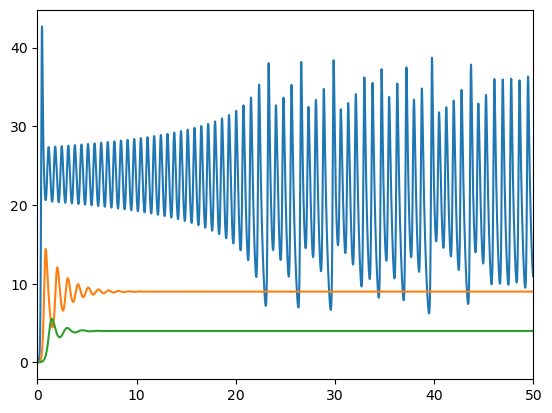

In [13]:
plt.plot(t25,xyz25[:, 2], label = 'r=25') 
plt.plot(t10,xyz10[:, 2], label = 'r=10') 
plt.plot(t5 ,xyz5 [:, 2], label = 'r=5 ') 

plt.xlim(0,50) 
plt.show

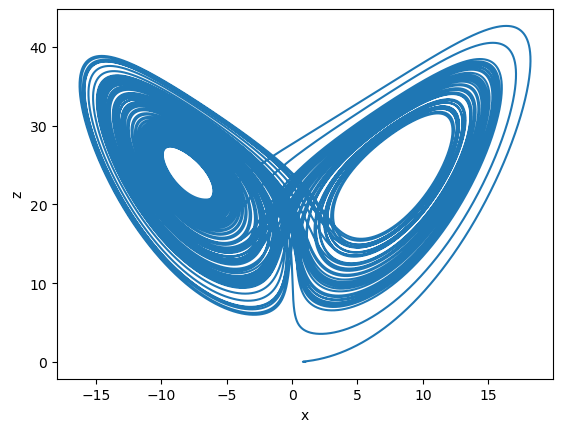

In [14]:
plt.plot( xyz25[:, 0], xyz25[:, 2], markersize = 0.7)

plt.xlabel('x') 
plt.ylabel('z') 

plt.show()

In [16]:

num_plotpoints = 999970

xyz = xyz25[30:] # removing the first 30s of transience


poincare_points = np.zeros((0,3))  #1st column = x Poincare plots, 2nd column = yPoincare points, 3rd column = z Poincare points
#poincare_points = np.append(poincare_points,np.array([[0,3,4]]),0) 

#for i in range (num_plotpoints-1) :
#    for n in range (len(t25)) :
#        x = sigma*(y-x)
#        if (x <0 and x > 0) or (:

x_poincare_points = [ ]
y_poincare_points = [ ]
z_poincare_points = [ ]
for i in range (num_plotpoints) : 
    x = xyz[i,0]
    xplus1 = xyz[i+1,0]
    if (x<0 and xplus1>0) or (x>0 and xplus1<0):
        x_poincare_points.append(x)
        y_poincare_points.append(xyz[i, 1] )
        z_poincare_points.append(xyz[i, 2] )  


In [ ]:
x_poincare_points

In [ ]:
xyz[:, 0] 

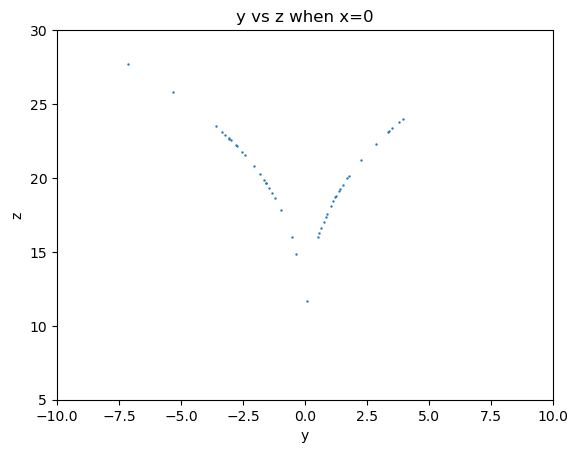

In [21]:
plt.plot(y_poincare_points, z_poincare_points, 'o', markersize = 0.7) 
plt.ylim(5,30) 
plt.xlim(-10, 10) 
plt.xlabel('y') 
plt.ylabel('z') 
plt.title('y vs z when x=0') 
plt.show()

In [26]:
num_plotpoints = 999970

xyz = xyz25[30:] # removing the first 30s of transience


poincare_points = np.zeros((0,3))  #1st column = x Poincare plots, 2nd column = yPoincare points, 3rd column = z Poincare points
#poincare_points = np.append(poincare_points,np.array([[0,3,4]]),0) 

#for i in range (num_plotpoints-1) :
#    for n in range (len(t25)) :
#        x = sigma*(y-x)
#        if (x <0 and x > 0) or (:

x_poincare_points = [ ]
y_poincare_points = [ ]
z_poincare_points = [ ]
for i in range (num_plotpoints) : 
    y = xyz[i,1]
    yplus1 = xyz[i+1,1]
    if (y<0 and yplus1>0) or (y>0 and yplus1<0):
        x_poincare_points.append(xyz[i, 0])
        y_poincare_points.append(y )
        z_poincare_points.append(xyz[i, 2] )  


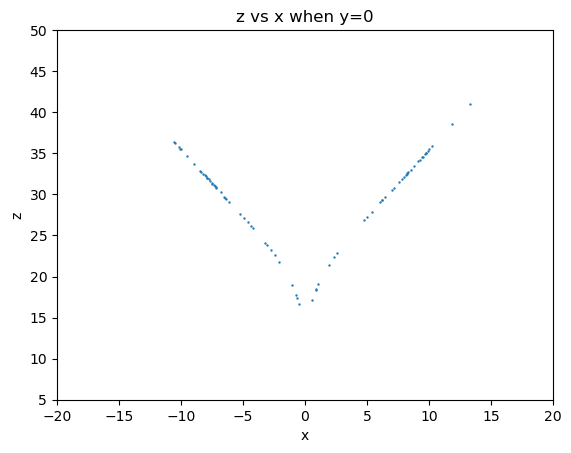

In [28]:
plt.plot(x_poincare_points, z_poincare_points, 'o', markersize = 0.7) 

plt.ylim(5,50) 
plt.xlim(-20, 20) 
plt.xlabel('x') 
plt.ylabel('z') 
plt.title('z vs x when y=0') 
plt.show()
plt.show()